## Бар (Bar)

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt 

## 1 Установливаем соединение с базой данных.

In [2]:
conn = sqlite3.connect('/Users/cleganeb/Desktop/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/data/checking-logs.sqlite')

## 2 Пронализируем пользователей из таблицы checker.

In [3]:
query = """
SELECT  uid, 
        timestamp
FROM checker
WHERE uid LIKE 'user_%'
ORDER BY uid ASC
"""
checker = pd.io.sql.read_sql(query, conn)

display(checker)

,uid,timestamp
0,user_0,2020-04-20 17:56:45.209722
1,user_0,2020-04-20 17:56:58.021415
2,user_0,2020-04-20 17:56:58.195472
3,user_1,2020-04-26 17:06:18.462708
4,user_1,2020-04-26 17:06:58.256753
...,...,...
3202,user_8,2020-05-14 21:12:17.314337
3203,user_8,2020-05-16 17:56:15.755553
3204,user_8,2020-05-16 17:57:48.867254
3205,user_8,2020-05-16 17:57:49.126243


## 3 Определим время суток каждого события.

In [4]:
checker['timestamp'] = pd.to_datetime(checker['timestamp'])
def time_period(hour):
    if 0 <= hour <= 3:
        return 'night'
    elif 4 <= hour <= 9:
        return 'morning'
    elif 10 <= hour <= 16:
        return 'afternoon'
    else:
        return 'evening'
    
checker['daytime'] = checker['timestamp'].dt.hour.map(time_period)
display(checker)

,uid,timestamp,daytime
0,user_0,2020-04-20 17:56:45.209722,evening
1,user_0,2020-04-20 17:56:58.021415,evening
2,user_0,2020-04-20 17:56:58.195472,evening
3,user_1,2020-04-26 17:06:18.462708,evening
4,user_1,2020-04-26 17:06:58.256753,evening
...,...,...,...
3202,user_8,2020-05-14 21:12:17.314337,evening
3203,user_8,2020-05-16 17:56:15.755553,evening
3204,user_8,2020-05-16 17:57:48.867254,evening
3205,user_8,2020-05-16 17:57:49.126243,evening


## 4 Посчитаем количество комитов по каждому дню и времени суток.

In [5]:
checker['date'] = checker['timestamp'].dt.date
grouped = checker.groupby(['date', 'daytime'])['uid'].count().unstack(fill_value=0)
display(grouped)
display(len(grouped))


daytime,afternoon,evening,morning,night
date,,,,
2020-04-17,10,0,13,0
2020-04-18,33,35,1,0
2020-04-19,16,11,4,2
2020-04-20,12,13,0,0
2020-04-21,0,25,0,0
2020-04-22,4,24,0,0
2020-04-23,15,20,6,2
2020-04-24,4,12,0,0
2020-04-25,33,49,21,1


35

## 5 Построим бар: размер шрифта должен быть 8, размер фигуры должен быть (15, 8).

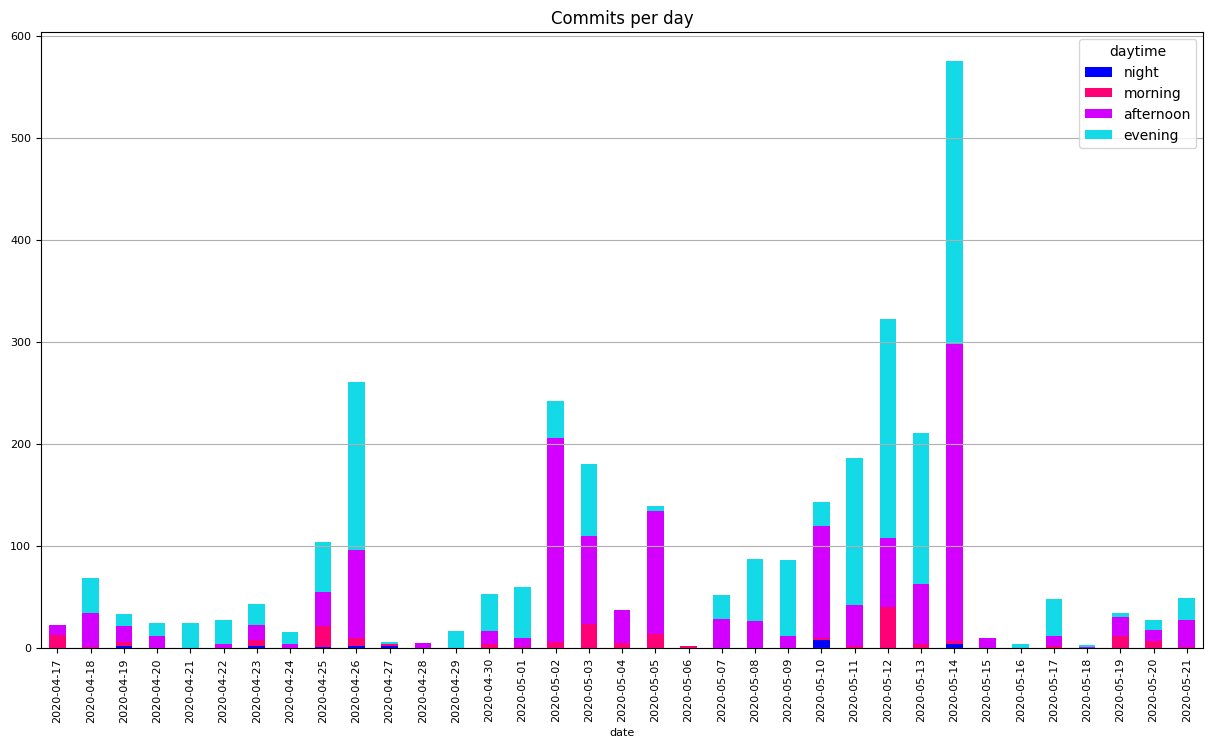

In [6]:
order = ["night", "morning", "afternoon", "evening"]
colors = {"night": "#0000FF", "morning": "#FF0077", "afternoon": "#D400FF", "evening": "#14D9E7"}
grouped = grouped.reindex(columns=order)


fig, ax = plt.subplots(figsize=(15, 8))
grouped.plot(
    ax=ax,
    kind='bar', 
    stacked=True,
    fontsize=8,
    color=[colors[col] for col in grouped.columns],
    title = 'Commits per day',
    xlabel ='date',
    ylabel = '')

ax.grid(axis='y')
ax.set_xlabel('date', fontsize=8)
ax.set_ylabel('', fontsize=8)
ax.legend(title='daytime', fontsize=10)

plt.show()

## 6 Когда наши пользователи обычно заходят в лаборатории: ночью, утром, днем ​​или вечером? 
## В какой день было:
## Наибольшее количество коммитов?
## Наибольшее количество коммитов, в котором вечером коммитов больше, чем днем?

In [7]:
most_common_times = grouped.sum().sort_values(ascending=False).head(2)
print(most_common_times.to_string(header=False))

max_commits_day = grouped.sum(axis=1).idxmax()
print("\nДень с наибольшим числом коммитов:", max_commits_day)

diff_evening_day = grouped['evening'] - grouped['afternoon']
filtered_days = diff_evening_day[diff_evening_day > 0]
max_commits_day = filtered_days.idxmax()
print("День с наибольшим числом коммитов, в котором вечером коммитов больше, чем днем:", max_commits_day)


evening      1611
afternoon    1391

День с наибольшим числом коммитов: 2020-05-14
День с наибольшим числом коммитов, в котором вечером коммитов больше, чем днем: 2020-05-12


## 7 Закроем соединение с базой данных.

In [8]:
conn.close()